In [43]:
import numpy as np
from boed.core.base import validate_positive_definite
from boed.core import make_u0
from boed.priors.kernels import Gaussian, Matern12, Matern32
from boed.priors.gp_priors import GaussianProcessPrior
from boed.core.noise import NoiseModel
from boed.pde.advection_diffusion import AdvectionDiffusion1D_CN
from boed.viz.boed_visualizer_pro import BOEDVisualizerPro
from boed.inference import LinearGaussianModel, ObservationMap
from boed.observations.sensors import SpaceTimeSensors
from boed.core.utils import compute_W,generate_synthetic_observations
import matplotlib.pyplot as plt 
from boed.design.criteria import DesignCriteria
from boed.design.greedy import run_greedy_oed_LG

SEED = 42
np.random.seed(SEED)

In [44]:
# ===============================================================================
# PARAMETERS
# ===============================================================================
N = 200
dt = 0.0025
n_steps = 250
diffusivity = 0.01
velocity = 0.5

In [45]:
model = AdvectionDiffusion1D_CN(N=N, dt=dt, diffusivity=diffusivity, velocity=velocity)
x_grid = np.linspace(0,1,N)

In [46]:
# ------------------- Prior -------------------
kernel = Matern32(length_scale=1, sigma=.1)
prior_process = GaussianProcessPrior(kernel, nx=N)
Sigma_prior = prior_process.Sigma
mu_prior = prior_process.mu
x_prior = prior_process.x
validate_positive_definite(Sigma_prior, "Prior covariance")


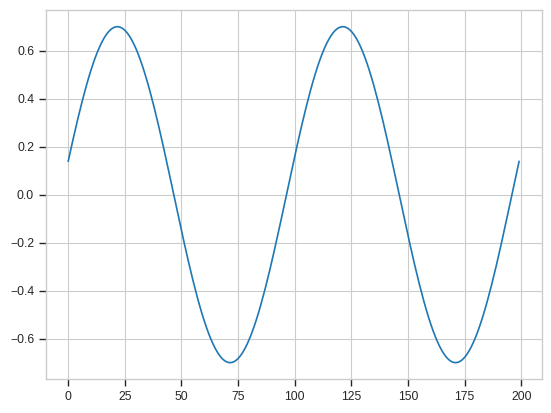

In [47]:
# ------------------- Synthetic data -------------------
u_true = make_u0(
    x_grid,
    "sine",
)
trajectory = model.evolve(u_true, n_steps)
plt.plot(u_true)


In [48]:
noise = NoiseModel(sigma_noise=0.001)
y_obs = trajectory + noise.sample(N, n_samples=n_steps+1)  # shape matches trajectory

A = model.get_forward_operator(n_steps=2)
y_final = y_obs[2, :]
Sigma_noise = noise.get_covariance(N)
print(y_final.shape)

(200,)


In [49]:
# --- Reconstruction de u0 (Condition Initiale) ---
lgm = LinearGaussianModel(A=A, Sigma_noise=Sigma_noise, mu_prior=mu_prior, Sigma_prior=Sigma_prior)
np.random.seed(42)
random_indices = np.random.choice(np.arange(N), 10, replace=False)

print(random_indices)
obs_map = ObservationMap.from_indices(random_indices, n_obs=N)

mu_post, Sigma_post = lgm.posterior(y_final, obs_map=obs_map)
print(f"EIG kl : {DesignCriteria.EIG(Sigma_post=Sigma_post, Sigma_prior=Sigma_prior)}")
print(f"EIG lgm : {lgm.expected_information_gain(obs_map=obs_map)}")
print(f"EIG obs : {DesignCriteria.eig_from_observation_cov(lgm.Sigma_Y(), Sigma_noise=Sigma_noise, obs_map=obs_map)}")
# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_post, Sigma_post,
    title="Reconstruction de la Condition Initiale (u0)",
    filename="reconstruction_u0.png"
)

[ 95  15  30 158 128 115  69 170 174  45]
EIG kl : 23.501349081559965
EIG lgm : 23.50134908155863
EIG obs : 23.50134908155863


In [50]:
lgm = LinearGaussianModel(A=A, Sigma_noise=Sigma_noise, mu_prior=mu_prior, Sigma_prior=Sigma_prior)

In [51]:
selected_design, _, _ = run_greedy_oed_LG(
    N=N,
    n_steps=n_steps,
    u_true=u_true,
    model=model,
    prior_kernel=prior_process,
    noise_model=noise,
    candidates_t=[2],
    candidates_x=np.arange(N),   # important: pool complet
    n_budget=10,
    criterion_type="EIG",        # si tu veux comparer sur EIG
)


--- Optimisation OED LG (Critère EIG) ---
Étape 1/10 : x=19, t=2 | Score: 4.6051e+00
Étape 2/10 : x=194, t=2 | Score: 9.0274e+00
Étape 3/10 : x=106, t=2 | Score: 1.2600e+01
Étape 4/10 : x=151, t=2 | Score: 1.5266e+01
Étape 5/10 : x=60, t=2 | Score: 1.7863e+01
Étape 6/10 : x=3, t=2 | Score: 1.9957e+01
Étape 7/10 : x=173, t=2 | Score: 2.1625e+01
Étape 8/10 : x=83, t=2 | Score: 2.3275e+01
Étape 9/10 : x=128, t=2 | Score: 2.4812e+01
Étape 10/10 : x=40, t=2 | Score: 2.6220e+01


In [52]:
selected_design_ELO, _, _ = run_greedy_oed_LG(
    N=N,
    n_steps=n_steps,
    u_true=u_true,
    model=model,
    prior_kernel=prior_process,
    noise_model=noise,
    candidates_t=[2],
    candidates_x=np.arange(N),   # important: pool complet
    n_budget=10,
    criterion_type="EIG_LINEAR_OBS",        # si tu veux comparer sur EIG
)

--- Optimisation OED LG (Critère EIG_LINEAR_OBS) ---
Étape 1/10 : x=33, t=2 | Score: 4.6051e+00
Étape 2/10 : x=194, t=2 | Score: 8.9924e+00
Étape 3/10 : x=113, t=2 | Score: 1.2469e+01
Étape 4/10 : x=4, t=2 | Score: 1.5379e+01
Étape 5/10 : x=155, t=2 | Score: 1.7922e+01
Étape 6/10 : x=73, t=2 | Score: 2.0273e+01
Étape 7/10 : x=175, t=2 | Score: 2.1809e+01
Étape 8/10 : x=133, t=2 | Score: 2.3292e+01
Étape 9/10 : x=53, t=2 | Score: 2.4742e+01
Étape 10/10 : x=93, t=2 | Score: 2.6119e+01


In [53]:
greedy_indices_ELO = [i[0] for k, i in enumerate(selected_design_ELO)]
print(greedy_indices_ELO)


[33, 194, 113, 4, 155, 73, 175, 133, 53, 93]


In [54]:
greedy_indices = [i[0] for k, i in enumerate(selected_design)]
print(greedy_indices)

[19, 194, 106, 151, 60, 3, 173, 83, 128, 40]


In [55]:
obs_map = ObservationMap.from_indices(greedy_indices_ELO, n_obs=N)

mu_post, Sigma_post = lgm.posterior(y_final, obs_map=obs_map)
print(f"EIG kl : {DesignCriteria.EIG(Sigma_post=Sigma_post, Sigma_prior=Sigma_prior)}")
print(f"EIG lgm : {lgm.expected_information_gain(obs_map=obs_map)}")
print(f"EIG obs : {DesignCriteria.eig_from_observation_cov(lgm.Sigma_Y(), Sigma_noise=Sigma_noise, obs_map=obs_map)}")


# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_post, Sigma_post,
    title="Reconstruction de la Condition Initiale (u0)",
    filename="reconstruction_u0_greedy_elo.png"
)

EIG kl : 26.119065636626146
EIG lgm : 26.11906563662339
EIG obs : 26.11906563662339


In [56]:
obs_map = ObservationMap.from_indices(greedy_indices, n_obs=N)

mu_post, Sigma_post = lgm.posterior(y_final, obs_map=obs_map)
print(f"EIG kl : {DesignCriteria.EIG(Sigma_post=Sigma_post, Sigma_prior=Sigma_prior)}")
print(f"EIG lgm : {lgm.expected_information_gain(obs_map=obs_map)}")
print(f"EIG obs : {DesignCriteria.eig_from_observation_cov(lgm.Sigma_Y(), Sigma_noise=Sigma_noise, obs_map=obs_map)}")


# --- Visualisation de la réussite ---
viz = BOEDVisualizerPro(output_dir="results")

# On compare mu_post à u_true (tous deux sont à t=0)
viz.plot_field(
    x_grid, u_true, mu_post, Sigma_post,
    title="Reconstruction de la Condition Initiale (u0)",
    filename="reconstruction_u0_greedy.png"
)

EIG kl : 26.219897242770458
EIG lgm : 26.21989724277404
EIG obs : 26.21989724277404
